In [1]:
# # Fast Results 
# ======================================
#     N             γ
# --------------------------------------
#     2      0.000003
#     3      0.000041
#     4      0.000079
#     5      0.000042
#     6      0.000067
#     7      0.000099
#     8      0.000172
#     9      0.000214
#    10      0.000227
#    11      0.000281
#    12      0.000356
#    13      0.000435
#    14      0.000482
# ======================================
# # QuTiP Results (small N)
# ======================================  
# === QuTiP backend (cross-check, small N) ===
#   N = 2 [qutip] … γ = 0.00001
#   N = 3 [qutip] … γ = 0.00004
#   N = 4 [qutip] … γ = 0.00023
#   N = 5 [qutip] … γ = 0.00013
#   N = 6 [qutip] … γ = 0.00019
#   N = 7 [qutip] … γ = 0.00031
#   N = 8 [qutip] … γ = 0.00042
#   N = 9 [qutip] … γ = 0.00053
#   N = 10 [qutip] … γ = 0.00062
#   N = 11 [qutip] … γ = 0.00092
#   N = 12 [qutip] … γ = 0.00098
# Qutip results takes 1000 minutes for N = 2 to N = 12, with higher N taking much longer 

# converting to np arrays fo    r plotting
N_fast = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
gamma_fast = [0.000003, 0.000041, 0.000079, 0.000042, 0.000067, 0.000099, 0.000172, 0.000214, 0.000227, 0.000281, 0.000356, 0.000435, 0.000482]
N_qt = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
gamma_qt = [0.00001, 0.00004, 0.00023, 0.00013, 0.00019, 0.00031, 0.00042, 0.00053, 0.00062, 0.00092, 0.00098]

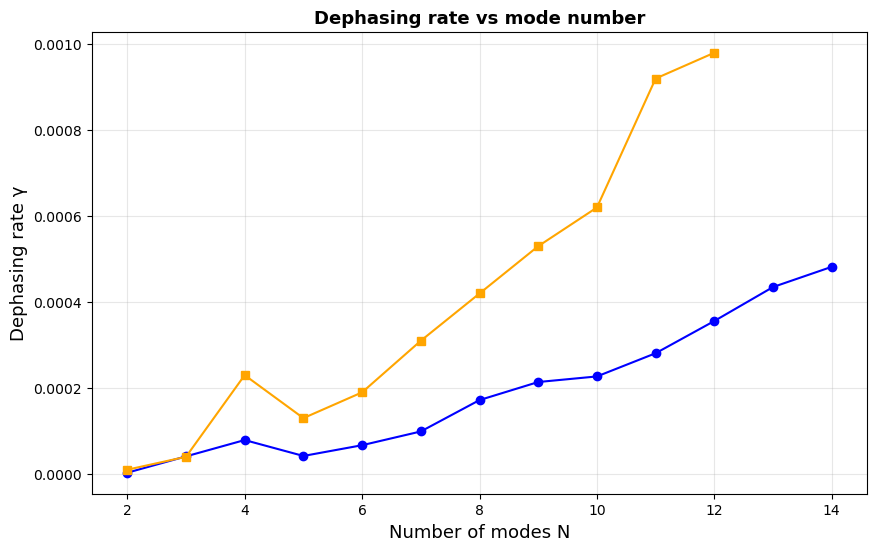

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(N_fast, gamma_fast, marker='o', label='Fast (numpy)', color='blue')
plt.plot(N_qt, gamma_qt, marker='s', label='QuTiP', color='orange')
plt.xlabel('Number of modes N', fontsize=13)
plt.ylabel('Dephasing rate γ', fontsize=13)
plt.title('Dephasing rate vs mode number', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)

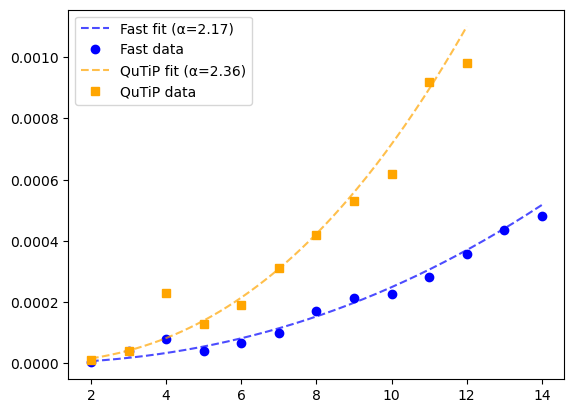

In [8]:
import numpy as np
# Try power law fit  to both data sets
def power_law_fit(N_range, gammas):
    log_fit = np.polyfit(np.log(N_range), np.log(gammas), 1)
    alpha   = log_fit[0]
    N_fine  = np.linspace(N_range[0], N_range[-1], 200)
    return alpha, N_fine, np.exp(log_fit[1]) * N_fine**alpha

# Plot with power law fits 
alpha_fast, N_fine_fast, gamma_fit_fast = power_law_fit(N_fast, gamma_fast)
alpha_qt, N_fine_qt, gamma_fit_qt = power_law_fit(N_qt, gamma_qt)
plt.plot(N_fine_fast, gamma_fit_fast, '--', color='blue', alpha=0.7, label=f'Fast fit (α={alpha_fast:.2f})')
plt.plot(N_fast, gamma_fast, 'o', color='blue', label='Fast data')
plt.plot(N_fine_qt, gamma_fit_qt, '--', color='orange', alpha=0.7, label=f'QuTiP fit (α={alpha_qt:.2f})')
plt.plot(N_qt, gamma_qt, 's', color='orange', label='QuTiP data')
plt.legend()
plt.show()